In [1]:
# # 🤖 Phase 10

# # Machine Learning

# ## Objectives

# - Data Preparation
# - Feature Selection
# - Train Test Split
# - Linear Regression
# - Decision Tree
# - Random Forest
# - Gradient Boosting
# - Model Evaluation
# - Feature Importance
# - Model Comparison

In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (

    RandomForestRegressor,

    GradientBoostingRegressor

)

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

In [3]:
master = pd.read_csv("../data/final/master_dataset_featured.csv")

master.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,...,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,...,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,...,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,...,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,...,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,...,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False


In [4]:
print(master.shape)

master.info()

(345374, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345374 entries, 0 to 345373
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   State                   345374 non-null  object 
 1   District                345374 non-null  object 
 2   Crop                    345374 non-null  object 
 3   Year                    345374 non-null  object 
 4   Season                  345374 non-null  object 
 5   Area                    345374 non-null  float64
 6   Area Units              345374 non-null  object 
 7   Production              340414 non-null  float64
 8   Production Units        345374 non-null  object 
 9   Yield                   345374 non-null  float64
 10  Start_Year              345374 non-null  int64  
 11  Year_yield              318023 non-null  float64
 12  Area_yield              318023 non-null  float64
 13  Production_yield        318023 non-null  float64
 14  fertili

In [5]:
ml = master.copy()

In [6]:
columns = [

    "State",

    "Crop",

    "Season",

    "Area",

    "Yield",

    "avg_temp_c",

    "total_rainfall_mm",

    "avg_humidity_percent",

    "N",

    "P",

    "K",

    "pH",

    "Production"

]

ml = ml[columns]

In [7]:
ml = ml.dropna()

ml.shape

(319451, 13)

In [8]:
## Label Encoding

In [9]:
encoder = LabelEncoder()

for col in [

    "State",

    "Crop",

    "Season"

]:

    ml[col] = encoder.fit_transform(ml[col])

In [10]:
## Train Test Split

In [11]:
X = ml.drop("Production",axis=1)

y = ml["Production"]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [13]:
## Linear Regression

In [14]:
lr = LinearRegression()

lr.fit(

    X_train,

    y_train

)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
pred_lr = lr.predict(X_test)

In [16]:
print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,pred_lr))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 :",r2_score(y_test,pred_lr))

Linear Regression
MAE : 1987475.4902239693
RMSE : 18681446.759403042
R2 : 0.15315431596246487


In [17]:
# ## Decision Tree

In [18]:
dt = DecisionTreeRegressor(

    random_state=42

)

dt.fit(

    X_train,

    y_train

)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
pred_dt = dt.predict(X_test)

In [20]:
print("Decision Tree")

print("MAE :",mean_absolute_error(y_test,pred_dt))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_dt)))

print("R2 :",r2_score(y_test,pred_dt))

Decision Tree
MAE : 61303.934248449026
RMSE : 1918867.423799245
R2 : 0.9910654392656987


In [23]:
## Random Forest

In [24]:
rf = RandomForestRegressor(

    n_estimators=150,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

,n_estimators,150
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
pred_rf = rf.predict(X_test)

In [26]:
print("Random Forest")

print("MAE :",mean_absolute_error(y_test,pred_rf))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :",r2_score(y_test,pred_rf))

Random Forest
MAE : 31229.595145275853
RMSE : 1236259.4874684808
R2 : 0.9962914636476966


In [27]:
## Gradient Boosting

In [28]:
gb = GradientBoostingRegressor(

    random_state=42

)

gb.fit(

    X_train,

    y_train

)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
pred_gb = gb.predict(X_test)

In [30]:
print("Gradient Boosting")

print("MAE :",mean_absolute_error(y_test,pred_gb))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_gb)))

print("R2 :",r2_score(y_test,pred_gb))

Gradient Boosting
MAE : 121289.64292215876
RMSE : 1604506.5682364523
R2 : 0.9937530754019998


In [31]:
## Model Comparison

In [32]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"

    ],

    "MAE":[

        mean_absolute_error(y_test,pred_lr),

        mean_absolute_error(y_test,pred_dt),

        mean_absolute_error(y_test,pred_rf),

        mean_absolute_error(y_test,pred_gb)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test,pred_lr)),

        np.sqrt(mean_squared_error(y_test,pred_dt)),

        np.sqrt(mean_squared_error(y_test,pred_rf)),

        np.sqrt(mean_squared_error(y_test,pred_gb))

    ],

    "R2":[

        r2_score(y_test,pred_lr),

        r2_score(y_test,pred_dt),

        r2_score(y_test,pred_rf),

        r2_score(y_test,pred_gb)

    ]

})

results.sort_values(

    "R2",

    ascending=False

)

,Model,MAE,RMSE,R2
2,Random Forest,3.122960e+04,1.236259e+06,0.996291
3,Gradient Boosting,1.212896e+05,1.604507e+06,0.993753
1,Decision Tree,6.130393e+04,1.918867e+06,0.991065
0,Linear Regression,1.987475e+06,1.868145e+07,0.153154


In [33]:
## Feature Importance

In [34]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
3,Area,6.766444e-01
4,Yield,3.118815e-01
7,avg_humidity_percent,4.803165e-03
6,total_rainfall_mm,3.135708e-03
5,avg_temp_c,1.533089e-03
11,pH,5.732969e-04
9,P,4.790567e-04
8,N,3.980382e-04
10,K,2.854867e-04
0,State,2.545724e-04


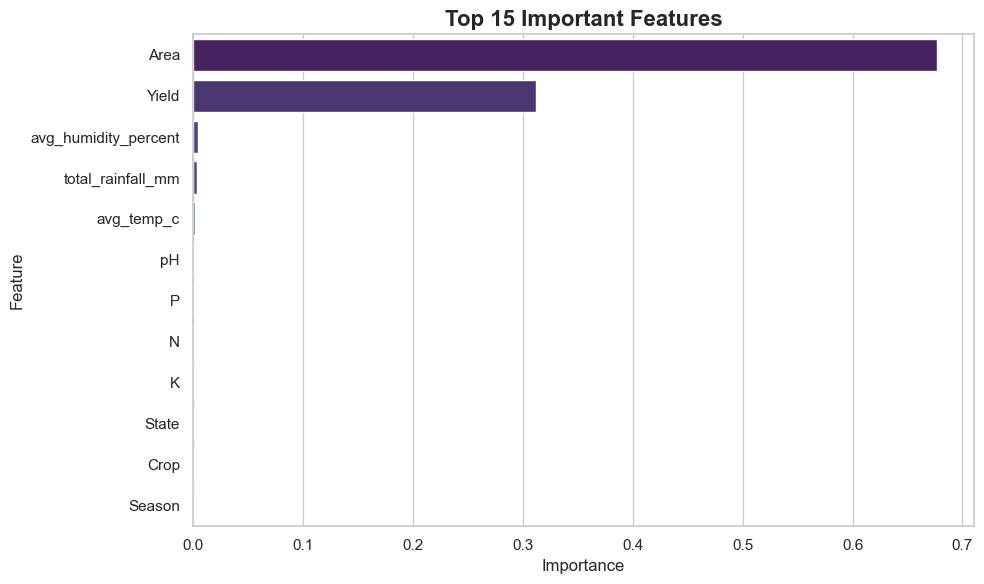

In [35]:
plt.figure(figsize=(10,6))

colors = sns.color_palette("viridis",15)

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette=colors

)

plt.title(

    "Top 15 Important Features",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

In [36]:
## Best Model

In [37]:
best = results.sort_values(

    "R2",

    ascending=False

).iloc[0]

best

Model     Random Forest
MAE        31229.595145
RMSE     1236259.487468
R2             0.996291
Name: 2, dtype: object

In [38]:
print("="*70)

print("PHASE 10 VERIFICATION")

print("="*70)

verification = pd.DataFrame({

    "Module":[

        "Data Preparation",

        "Encoding",

        "Train Test Split",

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting",

        "Feature Importance",

        "Model Comparison",

        "Verification"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "PASS"

    ]

})

display(verification)

PHASE 10 VERIFICATION


,Module,Status
0,Data Preparation,Completed
1,Encoding,Completed
2,Train Test Split,Completed
3,Linear Regression,Completed
4,Decision Tree,Completed
5,Random Forest,Completed
6,Gradient Boosting,Completed
7,Feature Importance,Completed
8,Model Comparison,Completed
9,Verification,PASS
